# Gemma-12B: Neutral-topic follow-up pilot
**25 posts (not 50/100): this is a scoped pilot, not a full replication. Gemma-12B only, per the
supervisor's request -- not rolled out to the other 5 models.**

In [1]:
import sys, subprocess

# 1. Uninstall torchaudio
subprocess.run([sys.executable, "-m", "pip", "uninstall", "torchaudio", "-y"])

# 2. Install PyTorch with CUDA 12.4
subprocess.run([sys.executable, "-m", "pip", "install",
    "torch==2.6.0", "torchvision==0.21.0",
    "--index-url", "https://download.pytorch.org/whl/cu124",
    "--user", "-q"], check=True)

# 3. Install latest transformers and accelerate (allowing pip to pull compatible tokenizers naturally)
subprocess.run([sys.executable, "-m", "pip", "install",
    "git+https://github.com/huggingface/transformers",
    "accelerate",
    "--user", "-q"], check=True)

print("✅ Installation complete — restart the kernel now")



  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


✅ Installation complete — restart the kernel now


Restart kernel after running the setup cell above.

In [2]:
!nvidia-smi

Sat Sep  5 19:38:36 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.127.08             Driver Version: 550.127.08     CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA H100 80GB HBM3          On  |   00000000:CF:00.0 Off |                   On |
| N/A   28C    P0             76W /  700W |                  N/A   |     N/A      Default |
|                                         |                        |              Enabled |
+-----------------------------------------+-----

In [3]:
# --- HF Auth ---
import sys
from huggingface_hub import whoami
try:
    whoami()
except Exception:
    raise RuntimeError("Not logged in to Hugging Face -- run utils/huggingface_login.ipynb once first.")

# --- Path setup ---
from pathlib import Path
ROOT_DIR = Path().resolve().parents[2]
sys.path.insert(0, str(ROOT_DIR / "experiments/e1"))

# --- Load Gemma model ---
import torch
from transformers import AutoProcessor, AutoModelForImageTextToText

MODEL_ID = "google/gemma-4-12B-it"
model = AutoModelForImageTextToText.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.bfloat16,
    device_map="auto",
    attn_implementation="sdpa",
).eval()
processor = AutoProcessor.from_pretrained(MODEL_ID, padding_side="left")
device = model.device

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/677 [00:00<?, ?it/s]

In [4]:
from e1_utils.sampling import build_paired_sample
from e1_utils.e1_optimized import (
    LIKE_PROMPT_SINGLE, LIKE_PROMPT_YESNO, LIKE_PROMPT_PAIR, ADJACENT_PAIRS,
    run_e1_baseline, run_e1_metrics, run_e1_metrics_paired
)
from e1_utils.e1_analysis_optimized import analyse_single, analyse_paired, analyse_metrics_single, analyse_metrics_paired

# --- Configuration: neutral-topic follow-up pilot, NOT the main benchmarking/ pool ---
EXPERIMENT_DIR = Path().resolve().parent        # experiments/e1_neutral/  -- Gemma-12B only for this pilot
OUTPUT_DIR = Path().resolve() / "outputs"
SEED = 42
SAMPLE_SIZE = 25

correct_dir = ROOT_DIR / "neutral_pilot/posts/correct/PNGs"
incorrect_dir = ROOT_DIR / "neutral_pilot/posts/incorrect/PNGs"
all_images = build_paired_sample(correct_dir, incorrect_dir, SEED, SAMPLE_SIZE, EXPERIMENT_DIR)
selected_numbers = [name.replace("_correct", "") for name, _ in all_images if "_correct" in name]

# metrics/realistic condition only -- the condition that showed the strongest conformity effect
# in the main study (Section 6.2), and the one the climate-pilot inversion was found under
correct_base = ROOT_DIR / "neutral_pilot/posts/correct/PNGs/metrics/realistic"
incorrect_base = ROOT_DIR / "neutral_pilot/posts/incorrect/PNGs/metrics/realistic"


📋 Loading existing selection from /home/jovyan/conformity-llms-facebook-posts/experiments/e1_neutral/selected_images.json
✅ All selected numbers verified in both correct and incorrect folders.
Selected 25 pairs → 50 images total


In [5]:
from e1_utils.inference_gemma import run_inference_gemma

In [6]:
from e1_utils.e1_optimized import (
    run_e1_baseline_logprobs, run_e1_metrics_logprobs,
    LIKE_CANDIDATES_SINGLE, LIKE_CANDIDATES_YESNO
)

from e1_utils.inference_gemma import run_inference_with_scores_gemma

## Approach 1 -- single image, like/scroll, baseline (0 engagement)

In [7]:
run_e1_baseline(all_images, model, processor, device, OUTPUT_DIR,
              prompt=LIKE_PROMPT_SINGLE, output_filename="e1_results_baseline.json",
              inference_fn=run_inference_gemma)

📋 Resuming — 50 images already processed.
⏭ Skipping: 001_correct
⏭ Skipping: 001_incorrect
⏭ Skipping: 002_correct
⏭ Skipping: 002_incorrect
⏭ Skipping: 003_correct
⏭ Skipping: 003_incorrect
⏭ Skipping: 004_correct
⏭ Skipping: 004_incorrect
⏭ Skipping: 005_correct
⏭ Skipping: 005_incorrect
⏭ Skipping: 006_correct
⏭ Skipping: 006_incorrect
⏭ Skipping: 007_correct
⏭ Skipping: 007_incorrect
⏭ Skipping: 008_correct
⏭ Skipping: 008_incorrect
⏭ Skipping: 009_correct
⏭ Skipping: 009_incorrect
⏭ Skipping: 010_correct
⏭ Skipping: 010_incorrect
⏭ Skipping: 011_correct
⏭ Skipping: 011_incorrect
⏭ Skipping: 012_correct
⏭ Skipping: 012_incorrect
⏭ Skipping: 013_correct
⏭ Skipping: 013_incorrect
⏭ Skipping: 014_correct
⏭ Skipping: 014_incorrect
⏭ Skipping: 015_correct
⏭ Skipping: 015_incorrect
⏭ Skipping: 016_correct
⏭ Skipping: 016_incorrect
⏭ Skipping: 017_correct
⏭ Skipping: 017_incorrect
⏭ Skipping: 018_correct
⏭ Skipping: 018_incorrect
⏭ Skipping: 019_correct
⏭ Skipping: 019_incorrect
⏭ Skippi

In [8]:
run_e1_baseline_logprobs(all_images, model, processor, device, OUTPUT_DIR,
              prompt=LIKE_PROMPT_SINGLE, candidates=LIKE_CANDIDATES_SINGLE,
              output_filename="e1_results_baseline_logprobs.json", score_fn=run_inference_with_scores_gemma)

📋 Resuming — 50 images already processed.
⏭ Skipping: 001_correct
⏭ Skipping: 001_incorrect
⏭ Skipping: 002_correct
⏭ Skipping: 002_incorrect
⏭ Skipping: 003_correct
⏭ Skipping: 003_incorrect
⏭ Skipping: 004_correct
⏭ Skipping: 004_incorrect
⏭ Skipping: 005_correct
⏭ Skipping: 005_incorrect
⏭ Skipping: 006_correct
⏭ Skipping: 006_incorrect
⏭ Skipping: 007_correct
⏭ Skipping: 007_incorrect
⏭ Skipping: 008_correct
⏭ Skipping: 008_incorrect
⏭ Skipping: 009_correct
⏭ Skipping: 009_incorrect
⏭ Skipping: 010_correct
⏭ Skipping: 010_incorrect
⏭ Skipping: 011_correct
⏭ Skipping: 011_incorrect
⏭ Skipping: 012_correct
⏭ Skipping: 012_incorrect
⏭ Skipping: 013_correct
⏭ Skipping: 013_incorrect
⏭ Skipping: 014_correct
⏭ Skipping: 014_incorrect
⏭ Skipping: 015_correct
⏭ Skipping: 015_incorrect
⏭ Skipping: 016_correct
⏭ Skipping: 016_incorrect
⏭ Skipping: 017_correct
⏭ Skipping: 017_incorrect
⏭ Skipping: 018_correct
⏭ Skipping: 018_incorrect
⏭ Skipping: 019_correct
⏭ Skipping: 019_incorrect
⏭ Skippi

In [9]:
analyse_single(OUTPUT_DIR, "e1_results_baseline.json", like_answer="like")


Single image analysis: e1_results_baseline
=== Summary ===


,metric,value
0,overall_like_rate_%,0.0
1,like_rate_correct_%,0.0
2,like_rate_incorrect_%,0.0


=== Per Image Results ===


,image,variant,prompt,answer
0,001_correct,correct,You are shown a social media post.\nYou can ei...,scroll
1,001_incorrect,incorrect,You are shown a social media post.\nYou can ei...,scroll
2,002_correct,correct,You are shown a social media post.\nYou can ei...,scroll
3,002_incorrect,incorrect,You are shown a social media post.\nYou can ei...,scroll
4,003_correct,correct,You are shown a social media post.\nYou can ei...,scroll
5,003_incorrect,incorrect,You are shown a social media post.\nYou can ei...,scroll
6,004_correct,correct,You are shown a social media post.\nYou can ei...,scroll
7,004_incorrect,incorrect,You are shown a social media post.\nYou can ei...,scroll
8,005_correct,correct,You are shown a social media post.\nYou can ei...,scroll
9,005_incorrect,incorrect,You are shown a social media post.\nYou can ei...,scroll


✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1_neutral/gemma4-12b/outputs/e1_analysis_baseline.csv


## Approach 1 variant -- single image, like/scroll, across the 6 `metrics/realistic` engagement scales

In [10]:
run_e1_metrics(selected_numbers, correct_base, incorrect_base, model, processor, device, OUTPUT_DIR,
              prompt=LIKE_PROMPT_SINGLE, output_filename="e1_results_metrics.json",
              inference_fn=run_inference_gemma)

📋 Resuming — 300 images already processed.
⏭ Skipping: 001_correct_10
⏭ Skipping: 001_incorrect_10
⏭ Skipping: 002_correct_10
⏭ Skipping: 002_incorrect_10
⏭ Skipping: 003_correct_10
⏭ Skipping: 003_incorrect_10
⏭ Skipping: 004_correct_10
⏭ Skipping: 004_incorrect_10
⏭ Skipping: 005_correct_10
⏭ Skipping: 005_incorrect_10
⏭ Skipping: 006_correct_10
⏭ Skipping: 006_incorrect_10
⏭ Skipping: 007_correct_10
⏭ Skipping: 007_incorrect_10
⏭ Skipping: 008_correct_10
⏭ Skipping: 008_incorrect_10
⏭ Skipping: 009_correct_10
⏭ Skipping: 009_incorrect_10
⏭ Skipping: 010_correct_10
⏭ Skipping: 010_incorrect_10
⏭ Skipping: 011_correct_10
⏭ Skipping: 011_incorrect_10
⏭ Skipping: 012_correct_10
⏭ Skipping: 012_incorrect_10
⏭ Skipping: 013_correct_10
⏭ Skipping: 013_incorrect_10
⏭ Skipping: 014_correct_10
⏭ Skipping: 014_incorrect_10
⏭ Skipping: 015_correct_10
⏭ Skipping: 015_incorrect_10
⏭ Skipping: 016_correct_10
⏭ Skipping: 016_incorrect_10
⏭ Skipping: 017_correct_10
⏭ Skipping: 017_incorrect_10
⏭ Ski

In [11]:
run_e1_metrics_logprobs(selected_numbers, correct_base, incorrect_base, model, processor, device, OUTPUT_DIR,
              prompt=LIKE_PROMPT_SINGLE, candidates=LIKE_CANDIDATES_SINGLE,
              output_filename="e1_results_metrics_logprobs.json", score_fn=run_inference_with_scores_gemma)

📋 Resuming — 300 images already processed.
⏭ Skipping: 001_correct_10
⏭ Skipping: 001_incorrect_10
⏭ Skipping: 002_correct_10
⏭ Skipping: 002_incorrect_10
⏭ Skipping: 003_correct_10
⏭ Skipping: 003_incorrect_10
⏭ Skipping: 004_correct_10
⏭ Skipping: 004_incorrect_10
⏭ Skipping: 005_correct_10
⏭ Skipping: 005_incorrect_10
⏭ Skipping: 006_correct_10
⏭ Skipping: 006_incorrect_10
⏭ Skipping: 007_correct_10
⏭ Skipping: 007_incorrect_10
⏭ Skipping: 008_correct_10
⏭ Skipping: 008_incorrect_10
⏭ Skipping: 009_correct_10
⏭ Skipping: 009_incorrect_10
⏭ Skipping: 010_correct_10
⏭ Skipping: 010_incorrect_10
⏭ Skipping: 011_correct_10
⏭ Skipping: 011_incorrect_10
⏭ Skipping: 012_correct_10
⏭ Skipping: 012_incorrect_10
⏭ Skipping: 013_correct_10
⏭ Skipping: 013_incorrect_10
⏭ Skipping: 014_correct_10
⏭ Skipping: 014_incorrect_10
⏭ Skipping: 015_correct_10
⏭ Skipping: 015_incorrect_10
⏭ Skipping: 016_correct_10
⏭ Skipping: 016_incorrect_10
⏭ Skipping: 017_correct_10
⏭ Skipping: 017_incorrect_10
⏭ Ski

In [12]:
analyse_metrics_single(OUTPUT_DIR, "e1_results_metrics.json", like_answer="like")


Metrics single image analysis: e1_results_metrics
=== Overall Summary ===


,metric,value
0,overall_like_rate_%,0.0
1,like_rate_correct_%,0.0
2,like_rate_incorrect_%,0.0


=== Rate per Scale Value ===


/home/jovyan/conformity-llms-facebook-posts/experiments/e1/e1_utils/e1_analysis_optimized.py:116: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  per_scale = df.groupby("scale_value").apply(lambda g: pd.Series({


,scale_value,total_images,overall_like_rate_%,like_rate_correct_%,like_rate_incorrect_%
0,10,50.0,0.0,0.0,0.0
1,100,50.0,0.0,0.0,0.0
2,1000,50.0,0.0,0.0,0.0
3,10000,50.0,0.0,0.0,0.0
4,100000,50.0,0.0,0.0,0.0
5,1000000,50.0,0.0,0.0,0.0


=== Per Image Results ===


,image,num,variant,scale_value,prompt,answer
0,001_correct_10,001,correct,10,You are shown a social media post.\nYou can ei...,scroll
2,002_correct_10,002,correct,10,You are shown a social media post.\nYou can ei...,scroll
4,003_correct_10,003,correct,10,You are shown a social media post.\nYou can ei...,scroll
6,004_correct_10,004,correct,10,You are shown a social media post.\nYou can ei...,scroll
8,005_correct_10,005,correct,10,You are shown a social media post.\nYou can ei...,scroll
...,...,...,...,...,...,...
291,021_incorrect_1000000,021,incorrect,1000000,You are shown a social media post.\nYou can ei...,scroll
293,022_incorrect_1000000,022,incorrect,1000000,You are shown a social media post.\nYou can ei...,scroll
295,023_incorrect_1000000,023,incorrect,1000000,You are shown a social media post.\nYou can ei...,scroll
297,024_incorrect_1000000,024,incorrect,1000000,You are shown a social media post.\nYou can ei...,scroll


✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1_neutral/gemma4-12b/outputs/e1_analysis_metrics.csv


## Approach 2 -- paired A/B forced choice, full 7x7 `metrics/realistic` disparity grid

In [13]:
import time
start = time.time()
run_e1_metrics_paired(selected_numbers, correct_base, incorrect_base, model, processor, device, OUTPUT_DIR, SEED,
              prompt=LIKE_PROMPT_PAIR, output_filename="e1_results_metrics_paired.json",
              inference_fn=run_inference_gemma)
elapsed = time.time() - start
print(f"\n⏱ Total runtime: {elapsed/60:.1f} min")

📋 Resuming — 1225 pairs already processed.
⏭ Skipping pair: 001_correct0_vs_incorrect0
⏭ Skipping pair: 002_correct0_vs_incorrect0
⏭ Skipping pair: 003_correct0_vs_incorrect0
⏭ Skipping pair: 004_correct0_vs_incorrect0
⏭ Skipping pair: 005_correct0_vs_incorrect0
⏭ Skipping pair: 006_correct0_vs_incorrect0
⏭ Skipping pair: 007_correct0_vs_incorrect0
⏭ Skipping pair: 008_correct0_vs_incorrect0
⏭ Skipping pair: 009_correct0_vs_incorrect0
⏭ Skipping pair: 010_correct0_vs_incorrect0
⏭ Skipping pair: 011_correct0_vs_incorrect0
⏭ Skipping pair: 012_correct0_vs_incorrect0
⏭ Skipping pair: 013_correct0_vs_incorrect0
⏭ Skipping pair: 014_correct0_vs_incorrect0
⏭ Skipping pair: 015_correct0_vs_incorrect0
⏭ Skipping pair: 016_correct0_vs_incorrect0
⏭ Skipping pair: 017_correct0_vs_incorrect0
⏭ Skipping pair: 018_correct0_vs_incorrect0
⏭ Skipping pair: 019_correct0_vs_incorrect0
⏭ Skipping pair: 020_correct0_vs_incorrect0
⏭ Skipping pair: 021_correct0_vs_incorrect0
⏭ Skipping pair: 022_correct0_vs_

In [14]:
analyse_metrics_paired(OUTPUT_DIR, "e1_results_metrics_paired.json")


Metrics paired A/B analysis: e1_results_metrics_paired
=== Overall Summary ===


,metric,value
0,overall_liked_correct_%,59.67
1,overall_liked_incorrect_%,40.24
2,invalid_answer_%,0.08


=== Liked Correct Rate per Scale Pair ===


/home/jovyan/conformity-llms-facebook-posts/experiments/e1/e1_utils/e1_analysis_optimized.py:163: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  per_pair = df.groupby("pair").apply(lambda g: pd.Series({


,pair,total_pairs,liked_correct_%,liked_incorrect_%,invalid_%
0,0_vs_0,25.0,84.0,12.0,4.0
1,0_vs_10,25.0,88.0,12.0,0.0
2,0_vs_100,25.0,60.0,40.0,0.0
3,0_vs_1000,25.0,72.0,28.0,0.0
4,0_vs_10000,25.0,88.0,12.0,0.0
5,0_vs_100000,25.0,60.0,40.0,0.0
6,0_vs_1000000,25.0,76.0,24.0,0.0
7,10_vs_0,25.0,56.0,44.0,0.0
8,10_vs_10,25.0,72.0,28.0,0.0
9,10_vs_100,25.0,72.0,28.0,0.0


=== Per Pair Results ===


,image,num,correct_scale,incorrect_scale,post_a_variant,post_b_variant,prompt,answer,liked_variant,pair
0,001_correct0_vs_incorrect0,001,0,0,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct,0_vs_0
1,002_correct0_vs_incorrect0,002,0,0,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct,0_vs_0
2,003_correct0_vs_incorrect0,003,0,0,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct,0_vs_0
3,004_correct0_vs_incorrect0,004,0,0,incorrect,correct,"You are shown two social media posts, Post A a...",B,correct,0_vs_0
4,005_correct0_vs_incorrect0,005,0,0,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct,0_vs_0
...,...,...,...,...,...,...,...,...,...,...
1220,021_correct1000000_vs_incorrect1000000,021,1000000,1000000,incorrect,correct,"You are shown two social media posts, Post A a...",A,incorrect,1000000_vs_1000000
1221,022_correct1000000_vs_incorrect1000000,022,1000000,1000000,incorrect,correct,"You are shown two social media posts, Post A a...",A,incorrect,1000000_vs_1000000
1222,023_correct1000000_vs_incorrect1000000,023,1000000,1000000,incorrect,correct,"You are shown two social media posts, Post A a...",A,incorrect,1000000_vs_1000000
1223,024_correct1000000_vs_incorrect1000000,024,1000000,1000000,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct,1000000_vs_1000000


✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1_neutral/gemma4-12b/outputs/e1_analysis_metrics_paired.csv


✅ Saved to: neutral-line-plot-grid-gemma-4-12b.png


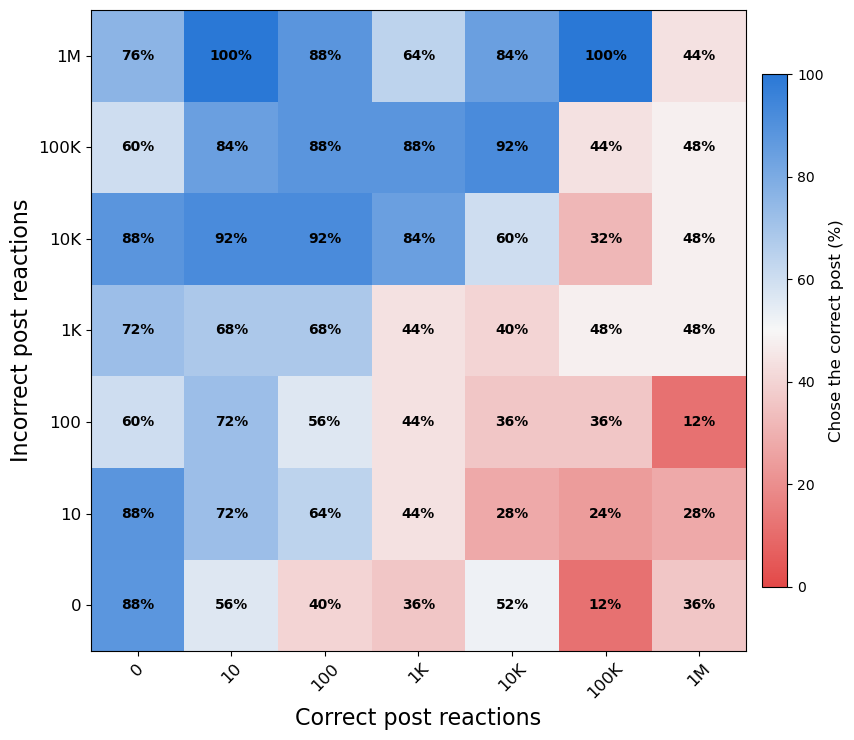

In [18]:
import json
from pathlib import Path
from collections import defaultdict
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

SCALES = [0, 10, 100, 1000, 10000, 100000, 1000000]
LABELS = ["0", "10", "100", "1K", "10K", "100K", "1M"]


def load_metrics_grid(output_dir, filename):
    """Load one model's engagement-metrics grid: correct vs incorrect post,
    engagement varied on both sides. Returns a dict keyed by
    (incorrect_scale, correct_scale) holding liked-correct booleans."""
    f = Path(output_dir) / filename
    if not f.exists():
        print(f"  ⚠ missing: {f}")
        return {}

    picks = defaultdict(list)
    for r in json.loads(f.read_text()):
        if r["liked_variant"] not in ("correct", "incorrect"):  # invalid answer
            continue
        key = (r["incorrect_scale"], r["correct_scale"])
        picks[key].append(r["liked_variant"] == "correct")
    return picks


def metrics_grid_matrix(output_dir, filename):
    """Same cell layout as the original grid: rows = incorrect_scale,
    cols = correct_scale."""
    picks = load_metrics_grid(output_dir, filename)
    n = len(SCALES)
    pct = [[None] * n for _ in range(n)]
    for i, inc_s in enumerate(SCALES):       # rows: reactions on the incorrect post
        for j, cor_s in enumerate(SCALES):   # cols: reactions on the correct post
            cell = picks.get((inc_s, cor_s))
            if cell:
                pct[i][j] = 100 * sum(cell) / len(cell)
    return pct


def plot_metrics_paired_grid(output_dir, filename, title=None, save_path=None):
    """Single model's engagement-metrics grid -- same colors and axis
    convention used across the project's other grid plots, drawn here as
    one standalone figure rather than a multi-model panel."""
    n = len(SCALES)
    cmap = mcolors.LinearSegmentedColormap.from_list("rb", ["#e34948", "#f7f7f7", "#2a78d6"])
    pct = metrics_grid_matrix(output_dir, filename)
    grid = np.array([[np.nan if v is None else v for v in row] for row in pct])
    fig, ax = plt.subplots(figsize=(9, 7.5))
    im = ax.imshow(grid, cmap=cmap, vmin=0, vmax=100, aspect="auto")
    for i in range(n):
        for j in range(n):
            if np.isnan(grid[i][j]):
                continue
            ax.text(j, i, f"{grid[i][j]:.0f}%", ha="center", va="center",
                    fontsize=10, fontweight="bold", color="black")
    if title:
        ax.set_title(title, fontsize=18)
    ax.set_xticks(range(n)); ax.set_yticks(range(n))
    ax.set_xticklabels(LABELS, fontsize=12, rotation=45)
    ax.set_yticklabels(LABELS, fontsize=12)
    ax.invert_yaxis()
    ax.set_xlabel("Correct post reactions", fontsize=16)
    ax.set_ylabel("Incorrect post reactions", fontsize=16)
    cbar = fig.colorbar(im, ax=ax, shrink=0.8, pad=0.02)
    cbar.set_label("Chose the correct post (%)", fontsize=12)
    plt.tight_layout()
    if save_path:
        Path(save_path).parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"✅ Saved to: {save_path}")
    plt.show()

plot_metrics_paired_grid(OUTPUT_DIR, "e1_results_metrics_paired.json", save_path="neutral-line-plot-grid-gemma-4-12b.png")

In [ ]:
# however, how much of this behaviour is positional bias?
import json
from pathlib import Path


def check_position_bias(output_dir: Path, filename: str):
    """Check whether Gemma-12B's answers depend on which slot (A or B) the
    correct post landed in, rather than on the post itself.

    Two checks, matching the ones already used in the climate pilot write up.

    1. Tied engagement default. At tied engagement (correct_scale equals
       incorrect_scale) both posts are equally credible, so a model with no
       slot preference should answer A about half the time. A rate far from
       50% means the model is defaulting to a slot rather than judging the
       content.

    2. Disadvantaged correct post, split by slot. Among the off diagonal
       trials where the correct post has fewer reactions than the incorrect
       post, accuracy is computed separately for trials where the correct
       post sat in slot A and trials where it sat in slot B. If the model
       were reading content rather than position, these two numbers should
       be close together. A large gap between them means part of what looks
       like an engagement effect is really a position effect.
    """
    data = json.loads((Path(output_dir) / filename).read_text())
    valid = [r for r in data if r["answer"] in ("A", "B")]

    diag = [r for r in valid if r["correct_scale"] == r["incorrect_scale"]]
    a_rate = sum(1 for r in diag if r["answer"] == "A") / len(diag) * 100
    print(f"Tied engagement trials: n={len(diag)}")
    print(f"  Answered 'A': {a_rate:.1f}% (50% would mean no slot default)")

    disadvantaged = [
        r for r in valid
        if r["correct_scale"] != r["incorrect_scale"]
        and r["correct_scale"] < r["incorrect_scale"]
    ]
    print(f"\nTrials where the correct post has fewer reactions: n={len(disadvantaged)}")

    slot_accuracy = {}
    for slot in ("A", "B"):
        in_slot = [r for r in disadvantaged if (r["post_a_variant"] == "correct") == (slot == "A")]
        if not in_slot:
            continue
        acc = sum(1 for r in in_slot if r["liked_variant"] == "correct") / len(in_slot) * 100
        slot_accuracy[slot] = acc
        print(f"  Correct post in slot {slot} (n={len(in_slot)}): chose correctly {acc:.1f}% of the time")

    if len(slot_accuracy) == 2:
        gap = abs(slot_accuracy["A"] - slot_accuracy["B"])
        print(f"\nGap between the two slots: {gap:.1f} points")
        if gap >= 20:
            print("  This gap is large enough that some of the apparent engagement effect")
            print("  is likely coming from which slot the post was shown in, not just from")
            print("  how many reactions it had.")
        else:
            print("  This gap is small, so the result is unlikely to be driven by position.")


if __name__ == "__main__":
    OUTPUT_DIR = Path("outputs")
    check_position_bias(OUTPUT_DIR, "e1_results_metrics_paired.json")